# Eye Liquid Spread Analysis - Control vs Glaucoma

Group analysis comparing **CONTROL** vs **all GLAUCOMA** cases (including both GLAUCOMA + URAMOX and GLAUCOMA - URAMOX).

**Comparisons:**
- Area over time (mean ± SD)
- Final area comparison (box plot + Mann-Whitney U)
- Velocity over time (mean ± SD)
- Mean and Max velocity comparison (box plot + Mann-Whitney U)

**Prerequisites:** Run `01_data_processing.ipynb` first to generate the data files.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [50]:
# Configuration
RESULTS_DIR = Path('./results')

# Colors for conditions
# Project-wide colors (match 03, 13, 15): CONTROL=blue, GLAUCOMA=red
condition_colors = {'CONTROL': '#377EB8', 'GLAUCOMA': '#E41A1C'}
LABEL_MAP = {'CONTROL': 'control', 'GLAUCOMA': 'glaucoma'}


## Load Data

In [51]:
# Load measurements
df_areas = pd.read_csv(RESULTS_DIR / 'eye_liquid_spread_measurements.csv')

print(f"Loaded {len(df_areas)} measurements from {df_areas['case'].nunique()} cases")
display(df_areas.head())

Loaded 934 measurements from 23 cases


,case,slide,time_sec,area_cm2,red_pixel_count,velocity_cm2_per_sec,group,condition
0,Case#1,Slide2.png,0.00,1.455394,30856,NaN,CONTROL,CONTROL
1,Case#1,Slide3.png,0.25,1.641941,34811,0.746187,CONTROL,CONTROL
2,Case#1,Slide4.png,0.50,1.845374,39124,0.813730,CONTROL,CONTROL
3,Case#1,Slide5.png,0.75,1.999564,42393,0.616760,CONTROL,CONTROL
4,Case#1,Slide6.png,1.00,2.154555,45679,0.619967,CONTROL,CONTROL


In [52]:
# Filter to only cases with assigned conditions
df_condition = df_areas[df_areas['condition'].notna()].copy()
conditions = ['CONTROL', 'GLAUCOMA']

print("Cases per condition:")
display(df_condition.groupby('condition')['case'].nunique().rename('n_cases'))

Cases per condition:


condition
CONTROL      8
GLAUCOMA    15
Name: n_cases, dtype: int64

## Area Comparison: GLAUCOMA vs CONTROL

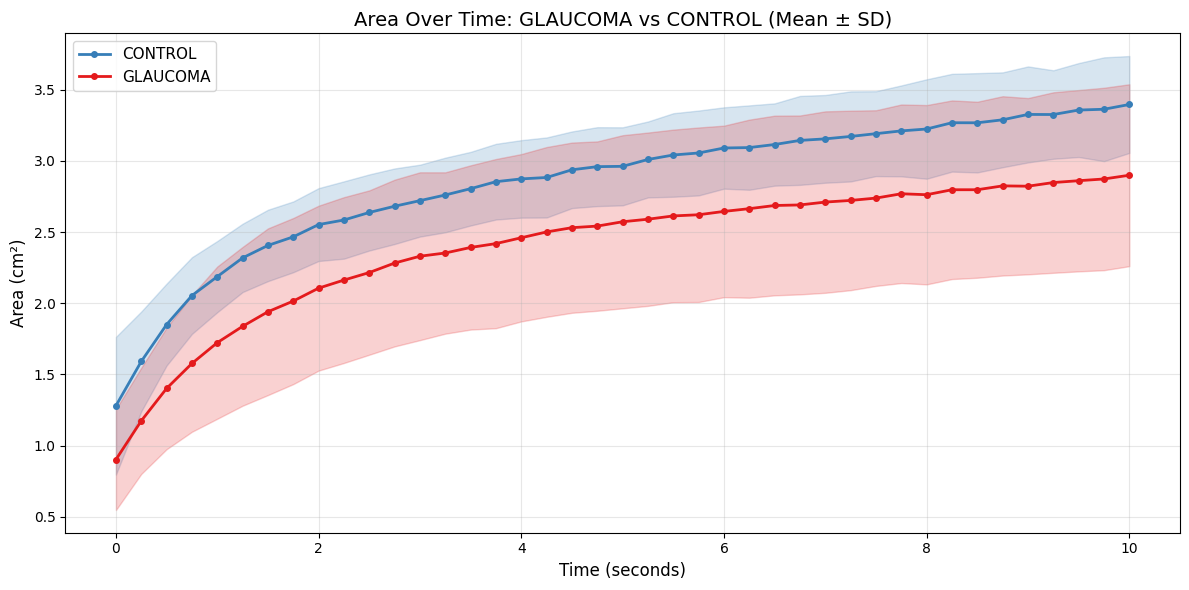

In [53]:
# Plot: Area over time (mean ± std)
fig, ax = plt.subplots(figsize=(12, 6))

for condition in conditions:
    cond_data = df_condition[df_condition['condition'] == condition]
    stats_cond = cond_data.groupby('time_sec')['area_cm2'].agg(['mean', 'std'])
    
    ax.plot(stats_cond.index, stats_cond['mean'], 'o-', label=LABEL_MAP.get(condition, condition), 
            color=condition_colors[condition], markersize=4, linewidth=2)
    ax.fill_between(stats_cond.index, 
                    stats_cond['mean'] - stats_cond['std'], 
                    stats_cond['mean'] + stats_cond['std'], 
                    alpha=0.2, color=condition_colors[condition])

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Area (cm²)', fontsize=12)
ax.set_title('Area Over Time: glaucoma vs control (Mean ± SD)', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/02_area_over_time_mean_sd.png', dpi=300, bbox_inches='tight')
plt.show()

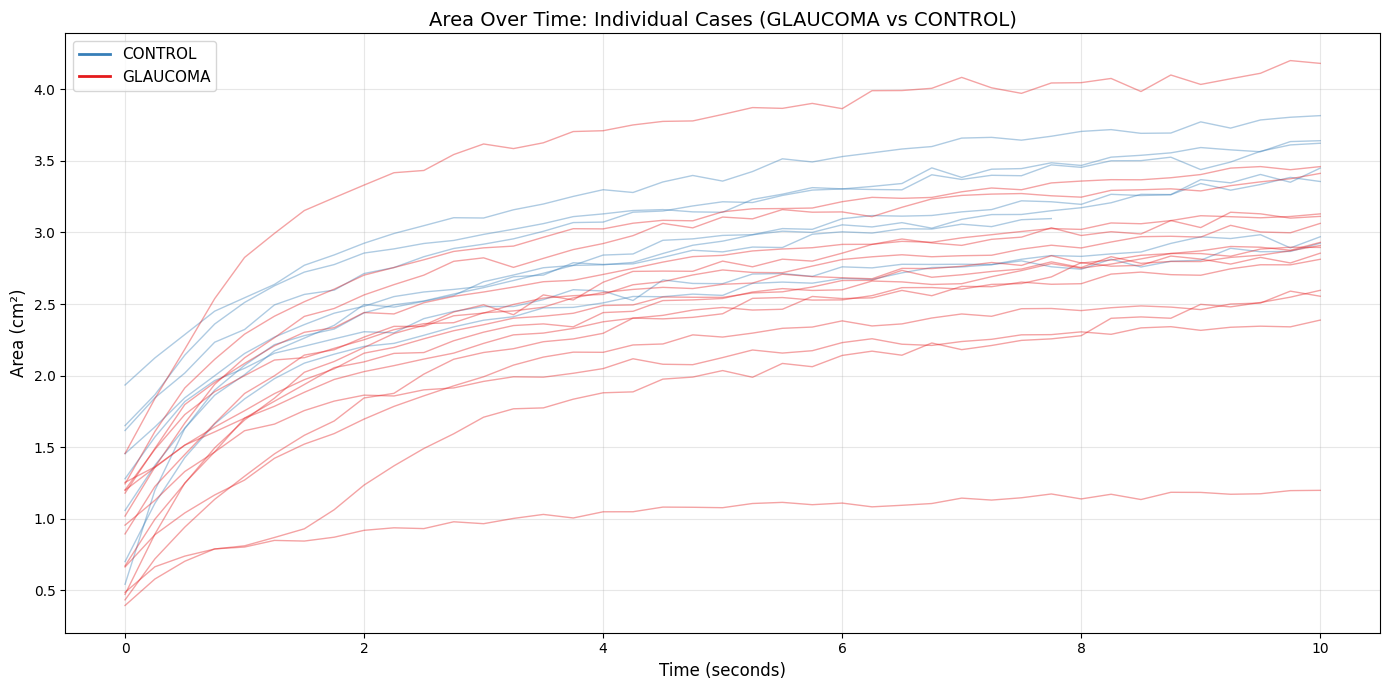

In [54]:
# Plot: Individual cases
fig, ax = plt.subplots(figsize=(14, 7))

for condition in conditions:
    cond_data = df_condition[df_condition['condition'] == condition]
    for case in cond_data['case'].unique():
        case_data = cond_data[cond_data['case'] == case]
        ax.plot(case_data['time_sec'], case_data['area_cm2'], '-', 
                color=condition_colors[condition], alpha=0.4, linewidth=1)

for condition in conditions:
    ax.plot([], [], '-', color=condition_colors[condition], label=LABEL_MAP.get(condition, condition), linewidth=2)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Area (cm²)', fontsize=12)
ax.set_title('Area Over Time: Individual Cases (glaucoma vs control)', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/02_area_over_time_individual.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
# Find the case with the lowest final area
idx_max_time = df_condition.groupby('case')['time_sec'].idxmax()
final_areas_cond = df_condition.loc[idx_max_time].reset_index(drop=True)
min_idx = final_areas_cond['area_cm2'].idxmin()
min_case = final_areas_cond.loc[min_idx, 'case']
min_area = final_areas_cond.loc[min_idx, 'area_cm2']
print(f'Lowest final area: {min_case}, area = {min_area:.4f} cm²')

Lowest final area: Case#19, area = 1.1992 cm²


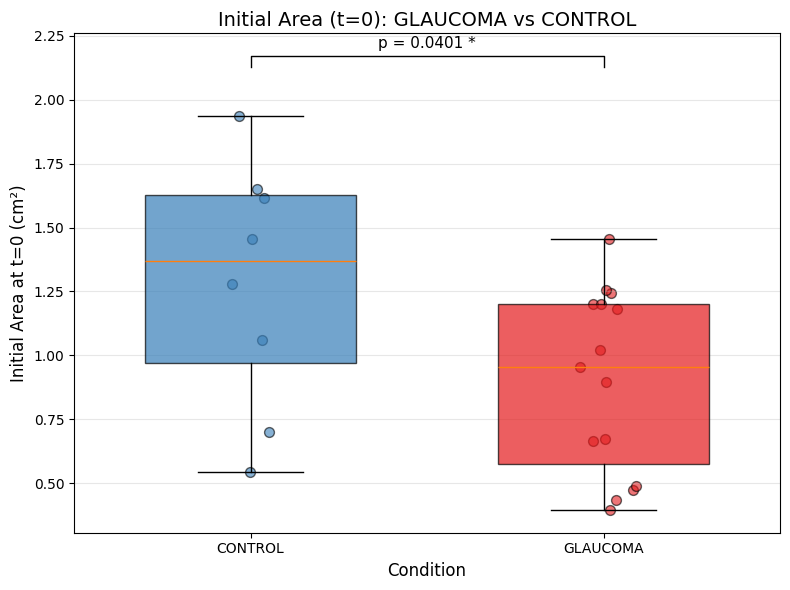


Mann-Whitney U test (Initial Area at t=0): statistic = 92.00, p-value = 0.0401
CONTROL initial area: mean = 1.280, std = 0.452 cm²
GLAUCOMA initial area: mean = 0.902, std = 0.343 cm²


In [56]:
# Box plot: Initial area (t=0) - Glaucoma vs Control with Mann-Whitney U test
initial_areas_cond = df_condition[df_condition['time_sec'] == 0.0][['case', 'condition', 'area_cm2']].copy()

control_initial = initial_areas_cond[initial_areas_cond['condition'] == 'CONTROL']['area_cm2'].values
glaucoma_initial = initial_areas_cond[initial_areas_cond['condition'] == 'GLAUCOMA']['area_cm2'].values

statistic, pvalue = stats.mannwhitneyu(control_initial, glaucoma_initial, alternative='two-sided')

fig, ax = plt.subplots(figsize=(8, 6))
box_data = [initial_areas_cond[initial_areas_cond['condition'] == c]['area_cm2'].values for c in conditions]

bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(c, c) for c in conditions], patch_artist=True, widths=0.6, showfliers=False)
for patch, cond in zip(bp['boxes'], conditions):
    patch.set_facecolor(condition_colors[cond])
    patch.set_alpha(0.7)

for i, cond in enumerate(conditions):
    y = initial_areas_cond[initial_areas_cond['condition'] == cond]['area_cm2'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=condition_colors[cond], edgecolor='black', s=50)

y_max = max(control_initial.max(), glaucoma_initial.max())
y_line = y_max * 1.1
ax.plot([1, 1, 2, 2], [y_line, y_line*1.02, y_line*1.02, y_line], 'k-', lw=1)
sig_text = f'p = {pvalue:.4f}' if pvalue >= 0.0001 else 'p < 0.0001'
if pvalue < 0.05:
    sig_text += ' *'
ax.text(1.5, y_line*1.03, sig_text, ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Initial Area at t=0 (cm²)', fontsize=12)
ax.set_xlabel('Condition', fontsize=12)
ax.set_title('Initial Area (t=0): glaucoma vs control', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig('figures/02_initial_area_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMann-Whitney U test (Initial Area at t=0): statistic = {statistic:.2f}, p-value = {pvalue:.4f}")
print(f"CONTROL initial area: mean = {control_initial.mean():.3f}, std = {control_initial.std():.3f} cm²")
print(f"GLAUCOMA initial area: mean = {glaucoma_initial.mean():.3f}, std = {glaucoma_initial.std():.3f} cm²")

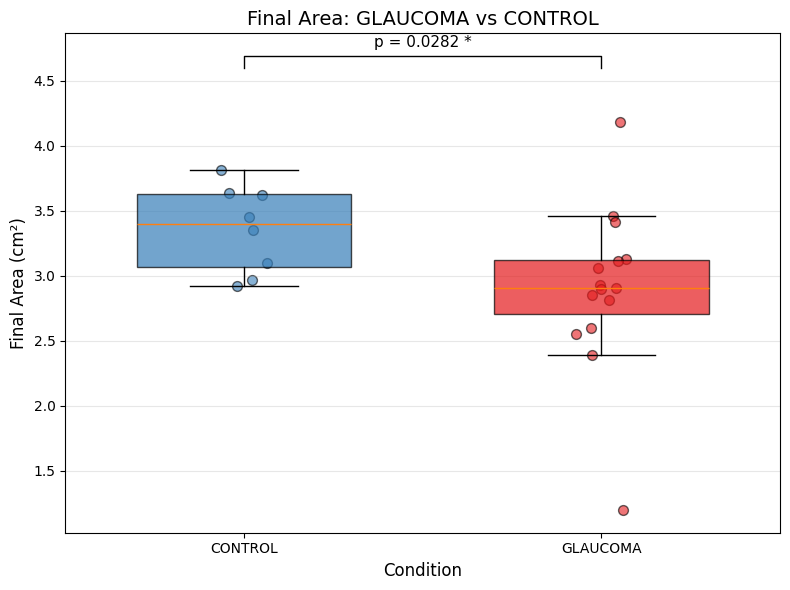


Mann-Whitney U test (Final Area): statistic = 94.00, p-value = 0.0282


In [57]:
# Box plot: Final area - Glaucoma vs Control with Mann-Whitney U test
idx_max_time = df_condition.groupby('case')['time_sec'].idxmax()
final_areas_cond = df_condition.loc[idx_max_time].reset_index(drop=True)

# Get data for each condition
control_areas = final_areas_cond[final_areas_cond['condition'] == 'CONTROL']['area_cm2'].values
glaucoma_areas = final_areas_cond[final_areas_cond['condition'] == 'GLAUCOMA']['area_cm2'].values

# Mann-Whitney U test
statistic, pvalue = stats.mannwhitneyu(control_areas, glaucoma_areas, alternative='two-sided')

fig, ax = plt.subplots(figsize=(8, 6))
box_data = [final_areas_cond[final_areas_cond['condition'] == c]['area_cm2'].values for c in conditions]

bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(c, c) for c in conditions], patch_artist=True, widths=0.6, showfliers=False)
for patch, cond in zip(bp['boxes'], conditions):
    patch.set_facecolor(condition_colors[cond])
    patch.set_alpha(0.7)

# Add individual points
for i, cond in enumerate(conditions):
    y = final_areas_cond[final_areas_cond['condition'] == cond]['area_cm2'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=condition_colors[cond], edgecolor='black', s=50)

# Add p-value annotation
y_max = max(control_areas.max(), glaucoma_areas.max())
y_line = y_max * 1.1
ax.plot([1, 1, 2, 2], [y_line, y_line*1.02, y_line*1.02, y_line], 'k-', lw=1)
sig_text = f'p = {pvalue:.4f}' if pvalue >= 0.0001 else 'p < 0.0001'
if pvalue < 0.05:
    sig_text += ' *'
ax.text(1.5, y_line*1.03, sig_text, ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Final Area (cm²)', fontsize=12)
ax.set_xlabel('Condition', fontsize=12)
ax.set_title('Final Area: glaucoma vs control', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig('figures/02_final_area_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMann-Whitney U test (Final Area): statistic = {statistic:.2f}, p-value = {pvalue:.4f}")

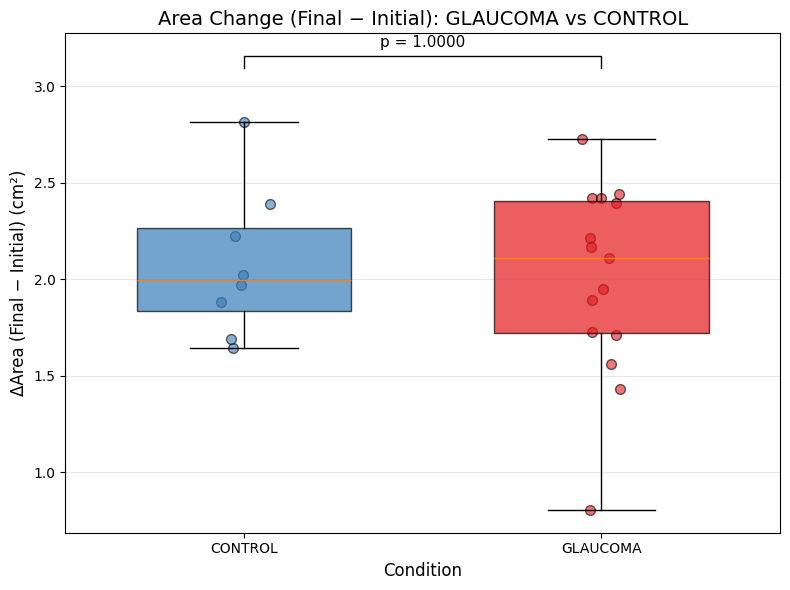


Mann-Whitney U test (Delta Area): statistic = 60.00, p-value = 1.0000


In [58]:
# Box plot: Delta area (final - initial) with Mann-Whitney U test
initial_areas_cond = df_condition[df_condition['time_sec'] == 0.0][['case', 'condition', 'area_cm2']].copy()
initial_areas_cond = initial_areas_cond.rename(columns={'area_cm2': 'initial_area'})

idx_max_time = df_condition.groupby('case')['time_sec'].idxmax()
final_areas_cond2 = df_condition.loc[idx_max_time][['case', 'area_cm2']].reset_index(drop=True)
final_areas_cond2 = final_areas_cond2.rename(columns={'area_cm2': 'final_area'})

delta_df = initial_areas_cond.merge(final_areas_cond2, on='case')
delta_df['delta_area'] = delta_df['final_area'] - delta_df['initial_area']

control_delta = delta_df[delta_df['condition'] == 'CONTROL']['delta_area'].values
glaucoma_delta = delta_df[delta_df['condition'] == 'GLAUCOMA']['delta_area'].values

statistic_d, pvalue_d = stats.mannwhitneyu(control_delta, glaucoma_delta, alternative='two-sided')

fig, ax = plt.subplots(figsize=(8, 6))
box_data_d = [delta_df[delta_df['condition'] == c]['delta_area'].values for c in conditions]

bp = ax.boxplot(box_data_d, labels=[LABEL_MAP.get(c, c) for c in conditions], patch_artist=True, widths=0.6, showfliers=False)
for patch, cond in zip(bp['boxes'], conditions):
    patch.set_facecolor(condition_colors[cond])
    patch.set_alpha(0.7)

for i, cond in enumerate(conditions):
    y = delta_df[delta_df['condition'] == cond]['delta_area'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=condition_colors[cond], edgecolor='black', s=50)

y_max = max(control_delta.max(), glaucoma_delta.max())
y_line = y_max * 1.1
ax.plot([1, 1, 2, 2], [y_line, y_line*1.02, y_line*1.02, y_line], 'k-', lw=1)
sig_text = f'p = {pvalue_d:.4f}' if pvalue_d >= 0.0001 else 'p < 0.0001'
if pvalue_d < 0.05:
    sig_text += ' *'
ax.text(1.5, y_line*1.03, sig_text, ha='center', va='bottom', fontsize=11)

ax.set_ylabel('ΔArea (Final − Initial) (cm²)', fontsize=12)
ax.set_xlabel('Condition', fontsize=12)
ax.set_title('Area Change (Final − Initial): glaucoma vs control', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig('figures/02_delta_area_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMann-Whitney U test (Delta Area): statistic = {statistic_d:.2f}, p-value = {pvalue_d:.4f}")

In [59]:
# Area statistics: Glaucoma vs Control
area_stats_condition = df_condition.groupby('condition')['area_cm2'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
area_stats_condition.columns = ['N observations', 'Mean Area', 'Std Area', 'Min Area', 'Max Area']

final_area_stats = final_areas_cond.groupby('condition')['area_cm2'].agg(['count', 'mean', 'std']).round(4)
final_area_stats.columns = ['N cases', 'Mean Final Area', 'Std Final Area']

print("\nArea Statistics: GLAUCOMA vs CONTROL")
print("\nAll time points:")
display(area_stats_condition)
print("\nFinal area per case:")
display(final_area_stats)


Area Statistics: GLAUCOMA vs CONTROL

All time points:


,N observations,Mean Area,Std Area,Min Area,Max Area
condition,,,,,
CONTROL,319,2.8278,0.5646,0.5433,3.8157
GLAUCOMA,615,2.3999,0.7451,0.3953,4.2001



Final area per case:


,N cases,Mean Final Area,Std Final Area
condition,,,
CONTROL,8,3.3594,0.3326
GLAUCOMA,15,2.8999,0.6390


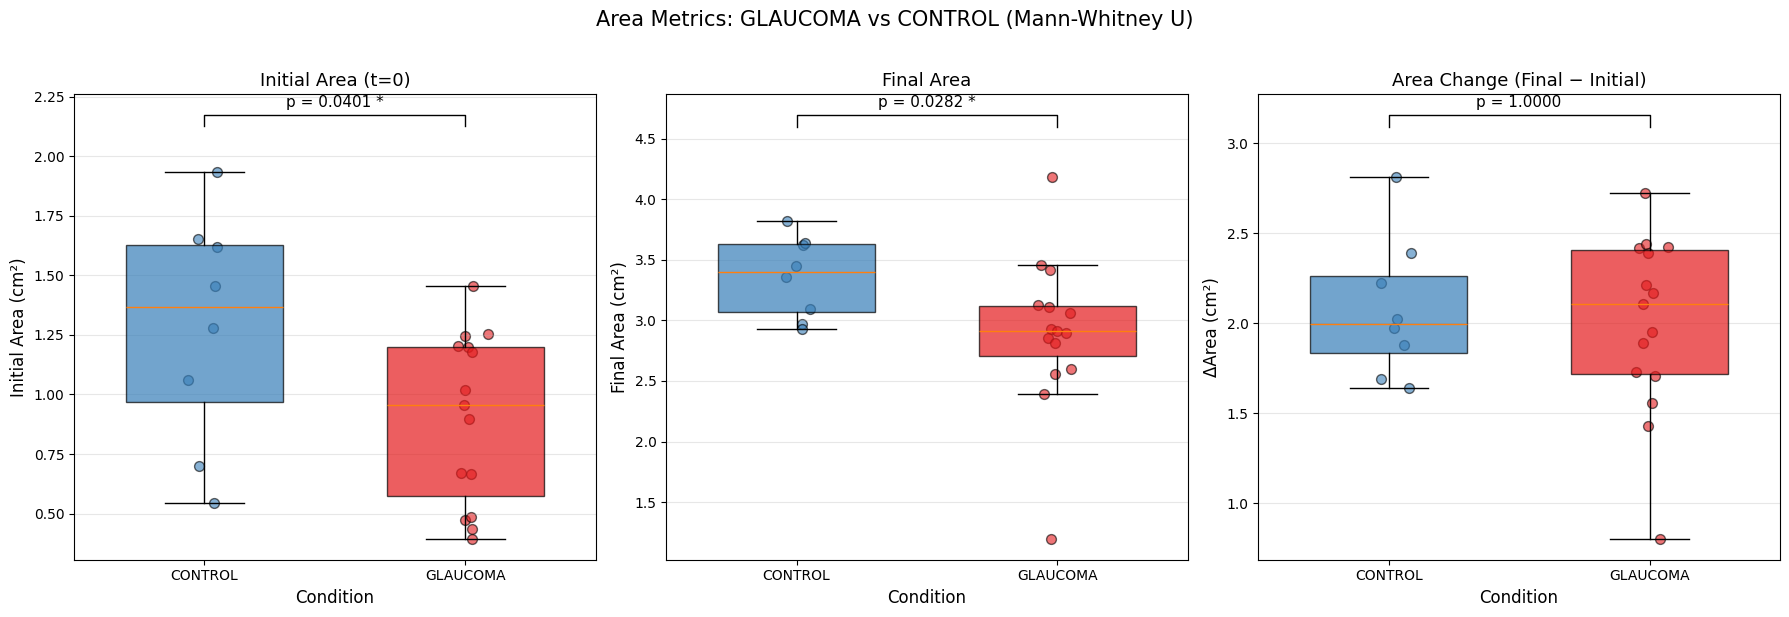

In [60]:
# Combined figure: Initial Area, Final Area, Area Change with Mann-Whitney U tests
initial_areas_cond = df_condition[df_condition['time_sec'] == 0.0][['case', 'condition', 'area_cm2']].copy()

idx_max_time = df_condition.groupby('case')['time_sec'].idxmax()
final_areas_cond = df_condition.loc[idx_max_time][['case', 'condition', 'area_cm2']].reset_index(drop=True)

delta_df = initial_areas_cond.rename(columns={'area_cm2': 'initial_area'}).merge(
    final_areas_cond.rename(columns={'area_cm2': 'final_area'})[['case', 'final_area']], on='case')
delta_df['delta_area'] = delta_df['final_area'] - delta_df['initial_area']

datasets = [
    {'data': initial_areas_cond, 'col': 'area_cm2', 'ylabel': 'Initial area (cm²)', 'title': 'Initial area (t=0)'},
    {'data': final_areas_cond, 'col': 'area_cm2', 'ylabel': 'Final area (cm²)', 'title': 'Final area'},
    {'data': delta_df, 'col': 'delta_area', 'ylabel': 'ΔArea (cm²)', 'title': 'Area change (final − initial)'},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ds in zip(axes, datasets):
    df_plot = ds['data']
    col = ds['col']

    control_vals = df_plot[df_plot['condition'] == 'CONTROL'][col].values
    glaucoma_vals = df_plot[df_plot['condition'] == 'GLAUCOMA'][col].values
    stat, pval = stats.mannwhitneyu(control_vals, glaucoma_vals, alternative='two-sided')

    box_data = [df_plot[df_plot['condition'] == c][col].values for c in conditions]
    bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(c, c) for c in conditions], patch_artist=True, widths=0.6, showfliers=False)
    for patch, cond in zip(bp['boxes'], conditions):
        patch.set_facecolor(condition_colors[cond])
        patch.set_alpha(0.7)

    for i, cond in enumerate(conditions):
        y = df_plot[df_plot['condition'] == cond][col].values
        x = np.random.normal(i + 1, 0.04, size=len(y))
        ax.scatter(x, y, alpha=0.6, color=condition_colors[cond], edgecolor='black', s=50)

    y_max = max(control_vals.max(), glaucoma_vals.max())
    y_line = y_max * 1.1
    ax.plot([1, 1, 2, 2], [y_line, y_line * 1.02, y_line * 1.02, y_line], 'k-', lw=1)
    sig_text = f'p = {pval:.4f}' if pval >= 0.0001 else 'p < 0.0001'
    if pval < 0.05:
        sig_text += ' *'
    ax.text(1.5, y_line * 1.03, sig_text, ha='center', va='bottom', fontsize=11)

    ax.set_ylabel(ds['ylabel'], fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_title(ds['title'], fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('figures/02_area_combined_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## Velocity Comparison: GLAUCOMA vs CONTROL

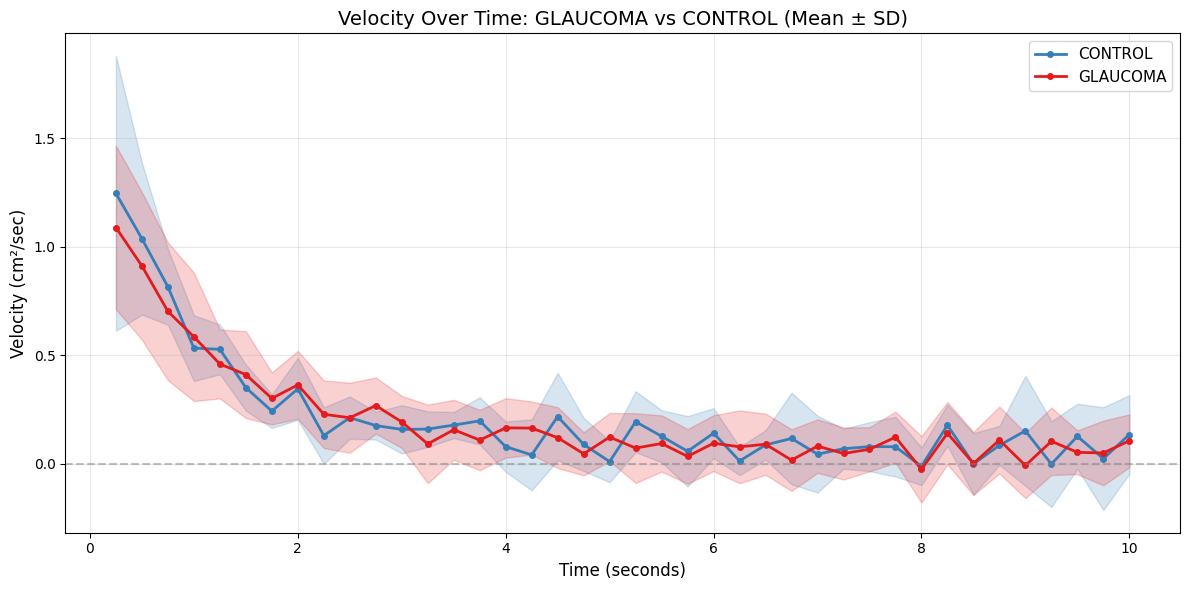

In [61]:
# Plot: Velocity over time - Glaucoma vs Control (mean ± std)
fig, ax = plt.subplots(figsize=(12, 6))

for condition in conditions:
    cond_data = df_condition[df_condition['condition'] == condition]
    stats_cond = cond_data.groupby('time_sec')['velocity_cm2_per_sec'].agg(['mean', 'std'])
    
    ax.plot(stats_cond.index, stats_cond['mean'], 'o-', label=LABEL_MAP.get(condition, condition), 
            color=condition_colors[condition], markersize=4, linewidth=2)
    ax.fill_between(stats_cond.index, 
                    stats_cond['mean'] - stats_cond['std'], 
                    stats_cond['mean'] + stats_cond['std'], 
                    alpha=0.2, color=condition_colors[condition])

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Velocity (cm²/sec)', fontsize=12)
ax.set_title('Velocity Over Time: glaucoma vs control (Mean ± SD)', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/02_velocity_over_time_mean_sd.png', dpi=300, bbox_inches='tight')
plt.show()

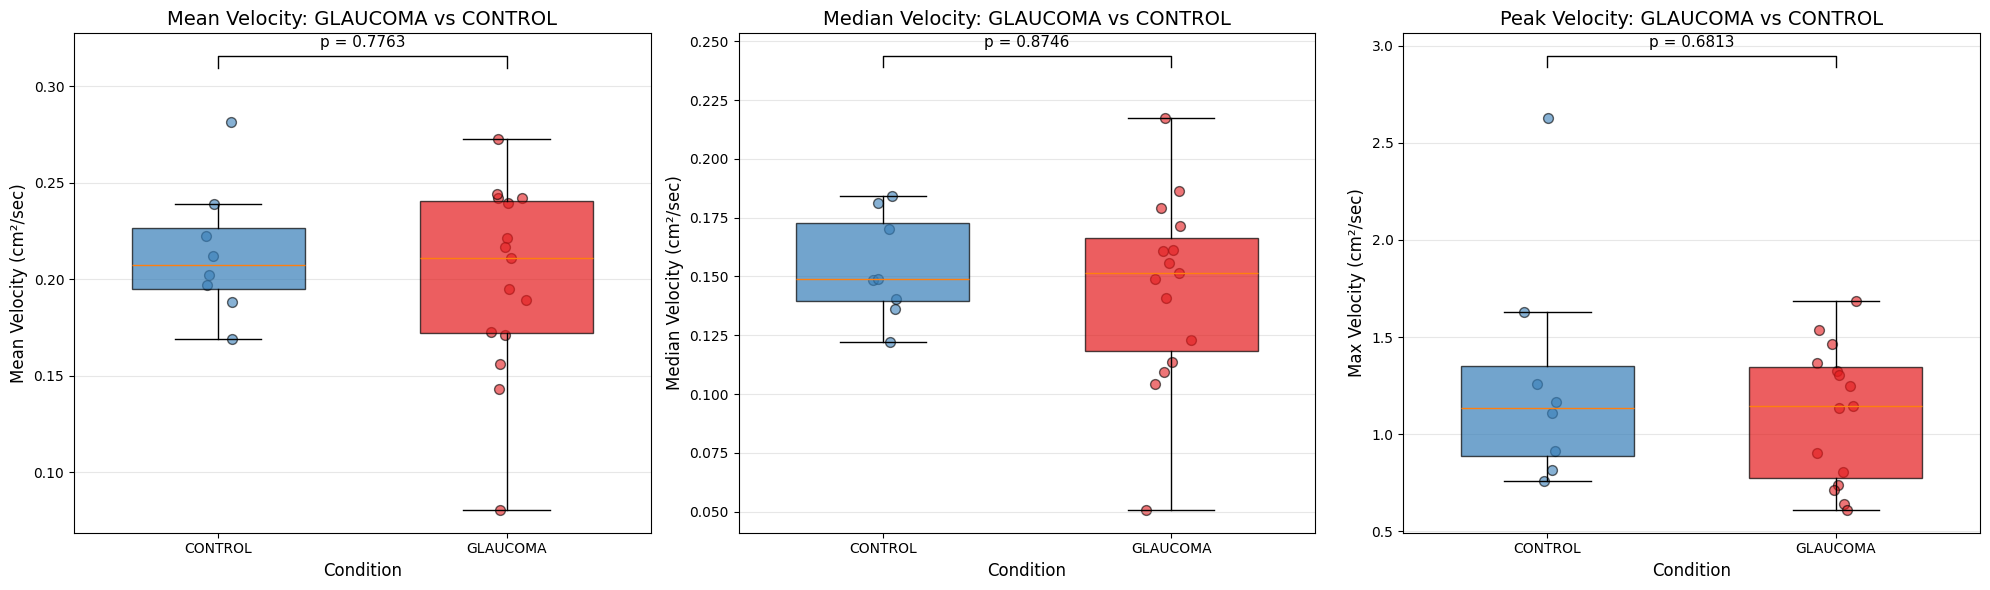


Mann-Whitney U tests:
  Mean velocity:   statistic = 65.00, p-value = 0.7763
  Median velocity: statistic = 63.00, p-value = 0.8746
  Max velocity:    statistic = 67.00, p-value = 0.6813


In [62]:
# Box plots: Mean, Median, and Max velocity - Glaucoma vs Control with Mann-Whitney U tests
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Mean velocity per case
mean_vel_cond = df_condition.groupby('case').agg({
    'velocity_cm2_per_sec': 'mean',
    'condition': 'first'
}).reset_index()

control_mean_vel = mean_vel_cond[mean_vel_cond['condition'] == 'CONTROL']['velocity_cm2_per_sec'].values
glaucoma_mean_vel = mean_vel_cond[mean_vel_cond['condition'] == 'GLAUCOMA']['velocity_cm2_per_sec'].values
stat_mean, pval_mean = stats.mannwhitneyu(control_mean_vel, glaucoma_mean_vel, alternative='two-sided')

ax = axes[0]
box_data = [mean_vel_cond[mean_vel_cond['condition'] == c]['velocity_cm2_per_sec'].values for c in conditions]
bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(c, c) for c in conditions], patch_artist=True, widths=0.6, showfliers=False)
for patch, cond in zip(bp['boxes'], conditions):
    patch.set_facecolor(condition_colors[cond])
    patch.set_alpha(0.7)
for i, cond in enumerate(conditions):
    y = mean_vel_cond[mean_vel_cond['condition'] == cond]['velocity_cm2_per_sec'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=condition_colors[cond], edgecolor='black', s=50)

y_max = max(control_mean_vel.max(), glaucoma_mean_vel.max())
y_line = y_max * 1.1
ax.plot([1, 1, 2, 2], [y_line, y_line*1.02, y_line*1.02, y_line], 'k-', lw=1)
sig_text = f'p = {pval_mean:.4f}' if pval_mean >= 0.0001 else 'p < 0.0001'
if pval_mean < 0.05:
    sig_text += ' *'
ax.text(1.5, y_line*1.03, sig_text, ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Mean Velocity (cm²/sec)', fontsize=12)
ax.set_xlabel('Condition', fontsize=12)
ax.set_title('Mean Velocity: glaucoma vs control', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Median velocity per case
median_vel_cond = df_condition.groupby('case').agg({
    'velocity_cm2_per_sec': 'median',
    'condition': 'first'
}).reset_index()

control_median_vel = median_vel_cond[median_vel_cond['condition'] == 'CONTROL']['velocity_cm2_per_sec'].values
glaucoma_median_vel = median_vel_cond[median_vel_cond['condition'] == 'GLAUCOMA']['velocity_cm2_per_sec'].values
stat_median, pval_median = stats.mannwhitneyu(control_median_vel, glaucoma_median_vel, alternative='two-sided')

ax = axes[1]
box_data = [median_vel_cond[median_vel_cond['condition'] == c]['velocity_cm2_per_sec'].values for c in conditions]
bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(c, c) for c in conditions], patch_artist=True, widths=0.6, showfliers=False)
for patch, cond in zip(bp['boxes'], conditions):
    patch.set_facecolor(condition_colors[cond])
    patch.set_alpha(0.7)
for i, cond in enumerate(conditions):
    y = median_vel_cond[median_vel_cond['condition'] == cond]['velocity_cm2_per_sec'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=condition_colors[cond], edgecolor='black', s=50)

y_max = max(control_median_vel.max(), glaucoma_median_vel.max())
y_line = y_max * 1.1
ax.plot([1, 1, 2, 2], [y_line, y_line*1.02, y_line*1.02, y_line], 'k-', lw=1)
sig_text = f'p = {pval_median:.4f}' if pval_median >= 0.0001 else 'p < 0.0001'
if pval_median < 0.05:
    sig_text += ' *'
ax.text(1.5, y_line*1.03, sig_text, ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Median Velocity (cm²/sec)', fontsize=12)
ax.set_xlabel('Condition', fontsize=12)
ax.set_title('Median Velocity: glaucoma vs control', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Max velocity per case
max_vel_cond = df_condition.groupby('case').agg({
    'velocity_cm2_per_sec': 'max',
    'condition': 'first'
}).reset_index()

control_max_vel = max_vel_cond[max_vel_cond['condition'] == 'CONTROL']['velocity_cm2_per_sec'].values
glaucoma_max_vel = max_vel_cond[max_vel_cond['condition'] == 'GLAUCOMA']['velocity_cm2_per_sec'].values
stat_max, pval_max = stats.mannwhitneyu(control_max_vel, glaucoma_max_vel, alternative='two-sided')

ax = axes[2]
box_data = [max_vel_cond[max_vel_cond['condition'] == c]['velocity_cm2_per_sec'].values for c in conditions]
bp = ax.boxplot(box_data, labels=[LABEL_MAP.get(c, c) for c in conditions], patch_artist=True, widths=0.6, showfliers=False)
for patch, cond in zip(bp['boxes'], conditions):
    patch.set_facecolor(condition_colors[cond])
    patch.set_alpha(0.7)
for i, cond in enumerate(conditions):
    y = max_vel_cond[max_vel_cond['condition'] == cond]['velocity_cm2_per_sec'].values
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.6, color=condition_colors[cond], edgecolor='black', s=50)

y_max = max(control_max_vel.max(), glaucoma_max_vel.max())
y_line = y_max * 1.1
ax.plot([1, 1, 2, 2], [y_line, y_line*1.02, y_line*1.02, y_line], 'k-', lw=1)
sig_text = f'p = {pval_max:.4f}' if pval_max >= 0.0001 else 'p < 0.0001'
if pval_max < 0.05:
    sig_text += ' *'
ax.text(1.5, y_line*1.03, sig_text, ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Max Velocity (cm²/sec)', fontsize=12)
ax.set_xlabel('Condition', fontsize=12)
ax.set_title('Peak Velocity: glaucoma vs control', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('figures/02_velocity_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMann-Whitney U tests:")
print(f"  Mean velocity:   statistic = {stat_mean:.2f}, p-value = {pval_mean:.4f}")
print(f"  Median velocity: statistic = {stat_median:.2f}, p-value = {pval_median:.4f}")
print(f"  Max velocity:    statistic = {stat_max:.2f}, p-value = {pval_max:.4f}")

In [63]:
# Velocity statistics: Glaucoma vs Control
velocity_stats_condition = df_condition.groupby('condition')['velocity_cm2_per_sec'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
velocity_stats_condition.columns = ['N observations', 'Mean Velocity', 'Std Velocity', 'Min Velocity', 'Max Velocity']

mean_vel_stats = mean_vel_cond.groupby('condition')['velocity_cm2_per_sec'].agg(['count', 'mean', 'std']).round(4)
mean_vel_stats.columns = ['N cases', 'Mean of Mean Velocity', 'Std of Mean Velocity']

max_vel_stats = max_vel_cond.groupby('condition')['velocity_cm2_per_sec'].agg(['count', 'mean', 'std']).round(4)
max_vel_stats.columns = ['N cases', 'Mean of Max Velocity', 'Std of Max Velocity']

print("\nVelocity Statistics: GLAUCOMA vs CONTROL")
print("\nAll time points:")
display(velocity_stats_condition)
print("\nMean velocity per case:")
display(mean_vel_stats)
print("\nMax velocity per case:")
display(max_vel_stats)


Velocity Statistics: GLAUCOMA vs CONTROL

All time points:


,N observations,Mean Velocity,Std Velocity,Min Velocity,Max Velocity
condition,,,,,
CONTROL,311,0.2139,0.3176,-0.3686,2.6274
GLAUCOMA,600,0.1998,0.2914,-0.3645,1.6836



Mean velocity per case:


,N cases,Mean of Mean Velocity,Std of Mean Velocity
condition,,,
CONTROL,8,0.2139,0.0345
GLAUCOMA,15,0.1998,0.0495



Max velocity per case:


,N cases,Mean of Max Velocity,Std of Max Velocity
condition,,,
CONTROL,8,1.2844,0.6101
GLAUCOMA,15,1.1072,0.3496


## Summary

In [64]:
print("="*60)
print("CONTROL vs GLAUCOMA ANALYSIS SUMMARY")
print("="*60)

print(f"\nSample sizes:")
print(f"  CONTROL: {len(control_areas)} cases")
print(f"  GLAUCOMA: {len(glaucoma_areas)} cases")

print(f"\n--- AREA ---")
print(f"Final Area (mean ± std):")
print(f"  CONTROL:  {control_areas.mean():.3f} ± {control_areas.std():.3f} cm²")
print(f"  GLAUCOMA: {glaucoma_areas.mean():.3f} ± {glaucoma_areas.std():.3f} cm²")
print(f"Mann-Whitney U: p = {pvalue:.4f}{'  *' if pvalue < 0.05 else ''}")

print(f"\n--- VELOCITY ---")
print(f"Mean Velocity (mean ± std):")
print(f"  CONTROL:  {control_mean_vel.mean():.4f} ± {control_mean_vel.std():.4f} cm²/sec")
print(f"  GLAUCOMA: {glaucoma_mean_vel.mean():.4f} ± {glaucoma_mean_vel.std():.4f} cm²/sec")
print(f"Mann-Whitney U: p = {pval_mean:.4f}{'  *' if pval_mean < 0.05 else ''}")

print(f"\nMax Velocity (mean ± std):")
print(f"  CONTROL:  {control_max_vel.mean():.4f} ± {control_max_vel.std():.4f} cm²/sec")
print(f"  GLAUCOMA: {glaucoma_max_vel.mean():.4f} ± {glaucoma_max_vel.std():.4f} cm²/sec")
print(f"Mann-Whitney U: p = {pval_max:.4f}{'  *' if pval_max < 0.05 else ''}")

CONTROL vs GLAUCOMA ANALYSIS SUMMARY

Sample sizes:
  CONTROL: 8 cases
  GLAUCOMA: 15 cases

--- AREA ---
Final Area (mean ± std):
  CONTROL:  3.359 ± 0.311 cm²
  GLAUCOMA: 2.900 ± 0.617 cm²
Mann-Whitney U: p = 0.0282  *

--- VELOCITY ---
Mean Velocity (mean ± std):
  CONTROL:  0.2139 ± 0.0323 cm²/sec
  GLAUCOMA: 0.1998 ± 0.0479 cm²/sec
Mann-Whitney U: p = 0.7763

Max Velocity (mean ± std):
  CONTROL:  1.2844 ± 0.5707 cm²/sec
  GLAUCOMA: 1.1072 ± 0.3377 cm²/sec
Mann-Whitney U: p = 0.6813
